# Energy & materials price intelligence

Exploratory analysis of five years of daily Brent crude oil and New York Harbor ultra-low-sulfur diesel prices. The goal is to understand market behavior, data quality, and the performance of a simple forecasting benchmark.

**Sources:** [FRED Brent Europe](https://fred.stlouisfed.org/series/DCOILBRENTEU) and [FRED New York Harbor diesel](https://fred.stlouisfed.org/series/DDFUELNYH), both published from U.S. Energy Information Administration data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'market_prices.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date').set_index('date')
df = df[['brent', 'gasoil']].apply(pd.to_numeric, errors='coerce')
df.index.name = 'date'

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)
df.head()

,brent,gasoil
date,,
2021-09-10,72.44,2.140
2021-09-13,72.97,2.160
2021-09-14,73.05,2.161
2021-09-15,74.84,2.207
2021-09-16,75.14,2.214


## 1. Coverage and source-quality checks

The two series are daily but do not publish on every calendar day. Missing values are retained rather than forward-filled so the analysis does not manufacture observations.

In [2]:
expected_days = (df.index.max() - df.index.min()).days + 1
calendar_gaps = df.index.to_series().diff().dropna().dt.days
quality_checks = pd.Series({
    'first observation': df.index.min().date(),
    'last observation': df.index.max().date(),
    'calendar days covered': expected_days,
    'rows in normalized file': len(df),
    'duplicate dates': int(df.index.duplicated().sum()),
    'missing Brent values': int(df['brent'].isna().sum()),
    'missing gasoil values': int(df['gasoil'].isna().sum()),
    'non-positive values': int((df[['brent', 'gasoil']] <= 0).sum().sum()),
    'largest calendar gap (days)': int(calendar_gaps.max()),
}, name='value').to_frame()
display(quality_checks)

coverage = df.notna().mean().mul(100).round(2).rename('coverage_pct').to_frame()
display(coverage)

,value
first observation,2021-09-10
last observation,2026-09-09
calendar days covered,1826
rows in normalized file,1287
duplicate dates,0
missing Brent values,24
missing gasoil values,41
non-positive values,0
largest calendar gap (days),4


,coverage_pct
brent,98.14
gasoil,96.81


## 2. Price trends

The series are plotted in separate panels because they have different units and price scales. A 30-observation rolling mean makes the medium-term direction easier to see without changing the underlying data.

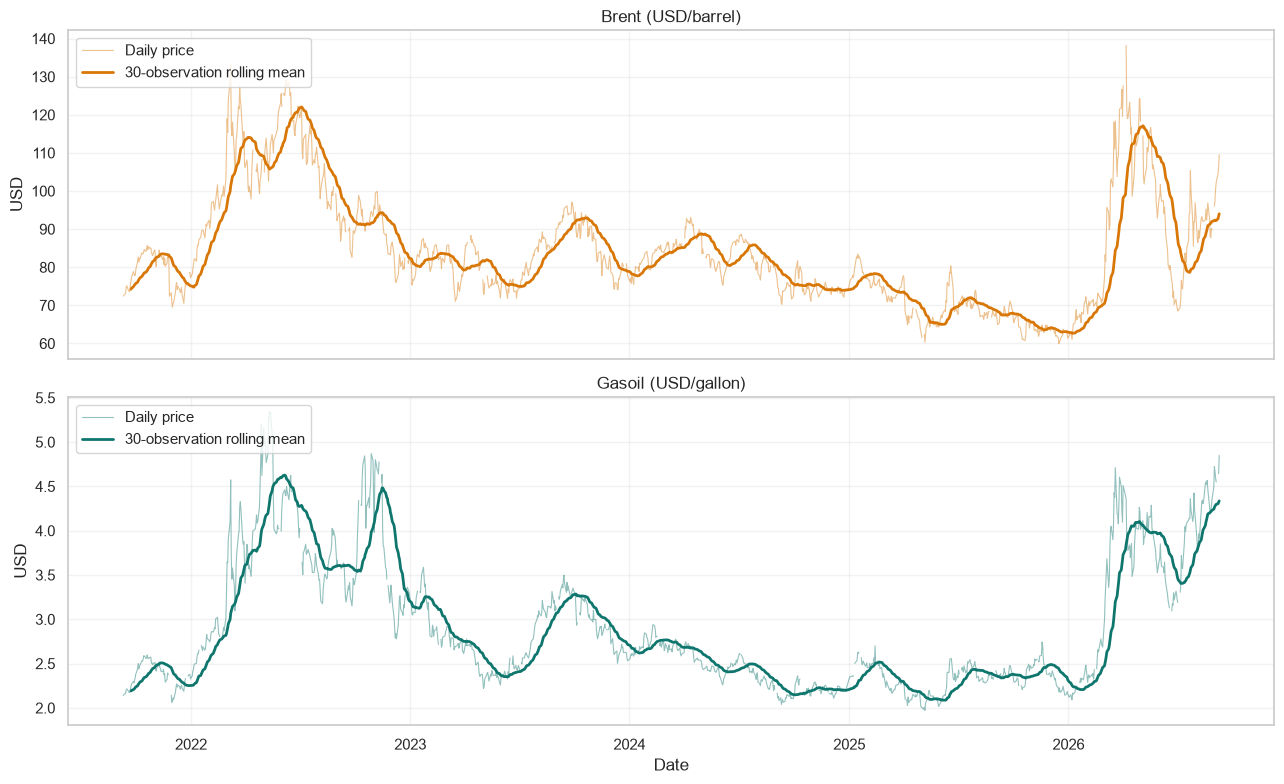

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
labels = {'brent': 'Brent (USD/barrel)', 'gasoil': 'Gasoil (USD/gallon)'}
colors = {'brent': '#d97706', 'gasoil': '#0f766e'}
for ax, column in zip(axes, ['brent', 'gasoil']):
    ax.plot(df.index, df[column], color=colors[column], alpha=0.45, linewidth=0.8, label='Daily price')
    ax.plot(df[column].rolling(30, min_periods=10).mean(), color=colors[column], linewidth=2, label='30-observation rolling mean')
    ax.set_title(labels[column])
    ax.set_ylabel('USD')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.25)
plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 3. Volatility

Volatility is measured here as the rolling standard deviation of daily percentage changes. This is more comparable across Brent and gasoil than comparing the raw price ranges.


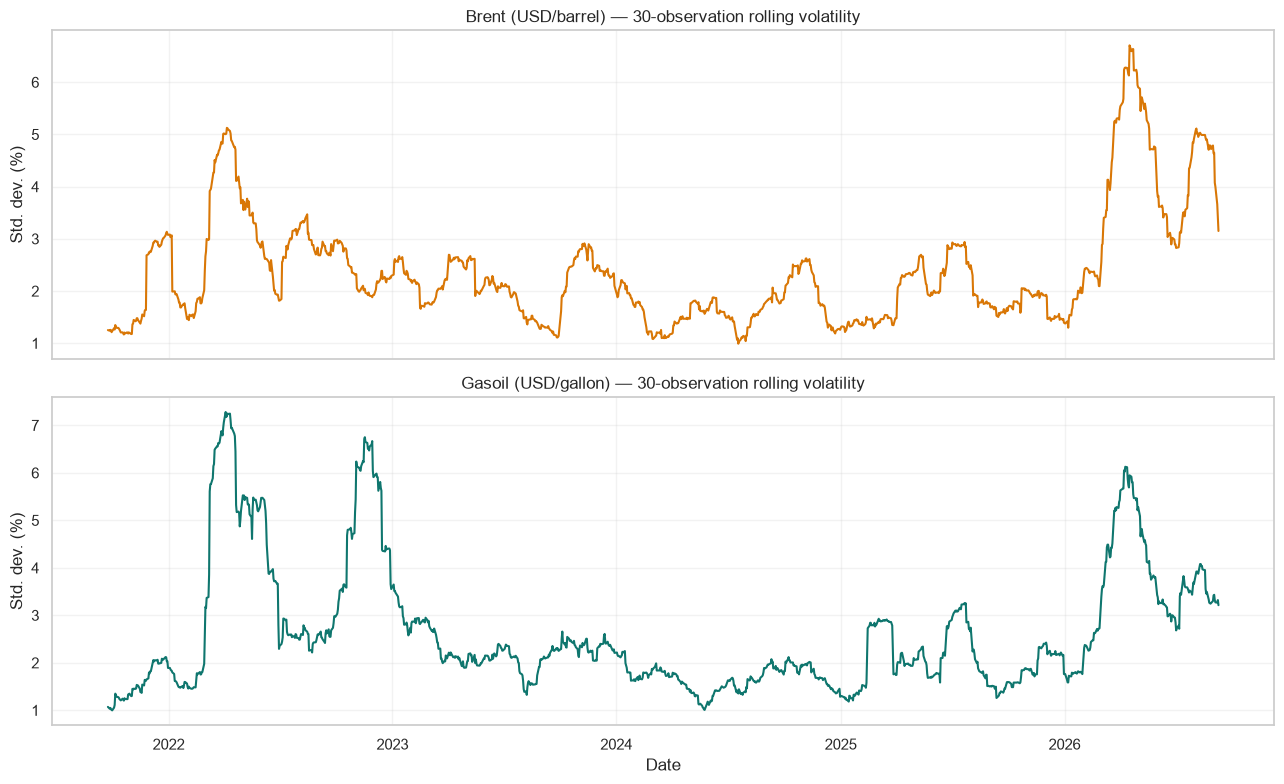

,mean,std,min,max
brent,2.365,1.079,0.991,6.706
gasoil,2.607,1.340,0.998,7.281


In [4]:
returns = df.pct_change(fill_method=None).mul(100)
rolling_volatility = returns.rolling(30, min_periods=10).std()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, column in zip(axes, ['brent', 'gasoil']):
    ax.plot(returns.index, rolling_volatility[column], color=colors[column], linewidth=1.5)
    ax.set_title(f'{labels[column]} — 30-observation rolling volatility')
    ax.set_ylabel('Std. dev. (%)')
    ax.grid(alpha=0.25)
plt.xlabel('Date')
plt.tight_layout()
plt.show()

volatility_summary = rolling_volatility[['brent', 'gasoil']].describe().T[['mean', 'std', 'min', 'max']].round(3)
volatility_summary

## 4. Correlation

Price-level correlation can be inflated by common trends. The return correlation is therefore the more useful signal for short-term co-movement, while both views are shown for transparency.

,level correlation,return correlation
brent,1.000,1.000
gasoil,0.817,0.612


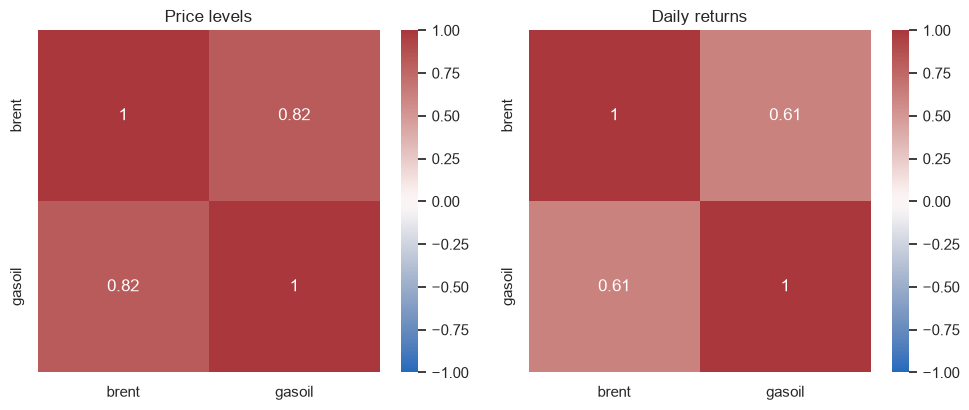

In [5]:
level_correlation = df[['brent', 'gasoil']].corr().round(3)
# Pair returns over exactly the same source-date intervals.
paired_returns = df[['brent', 'gasoil']].dropna().pct_change(fill_method=None)
return_correlation = paired_returns.corr().round(3)
display(pd.DataFrame({'level correlation': level_correlation.iloc[:, 0], 'return correlation': return_correlation.iloc[:, 0]}).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(level_correlation, annot=True, vmin=-1, vmax=1, cmap='vlag', ax=axes[0], square=True)
axes[0].set_title('Price levels')
sns.heatmap(return_correlation, annot=True, vmin=-1, vmax=1, cmap='vlag', ax=axes[1], square=True)
axes[1].set_title('Daily returns')
plt.tight_layout()
plt.show()


## 5. Seasonality

Boxplots show the distribution of daily returns by month and weekday. They help distinguish recurring calendar effects from isolated shocks.

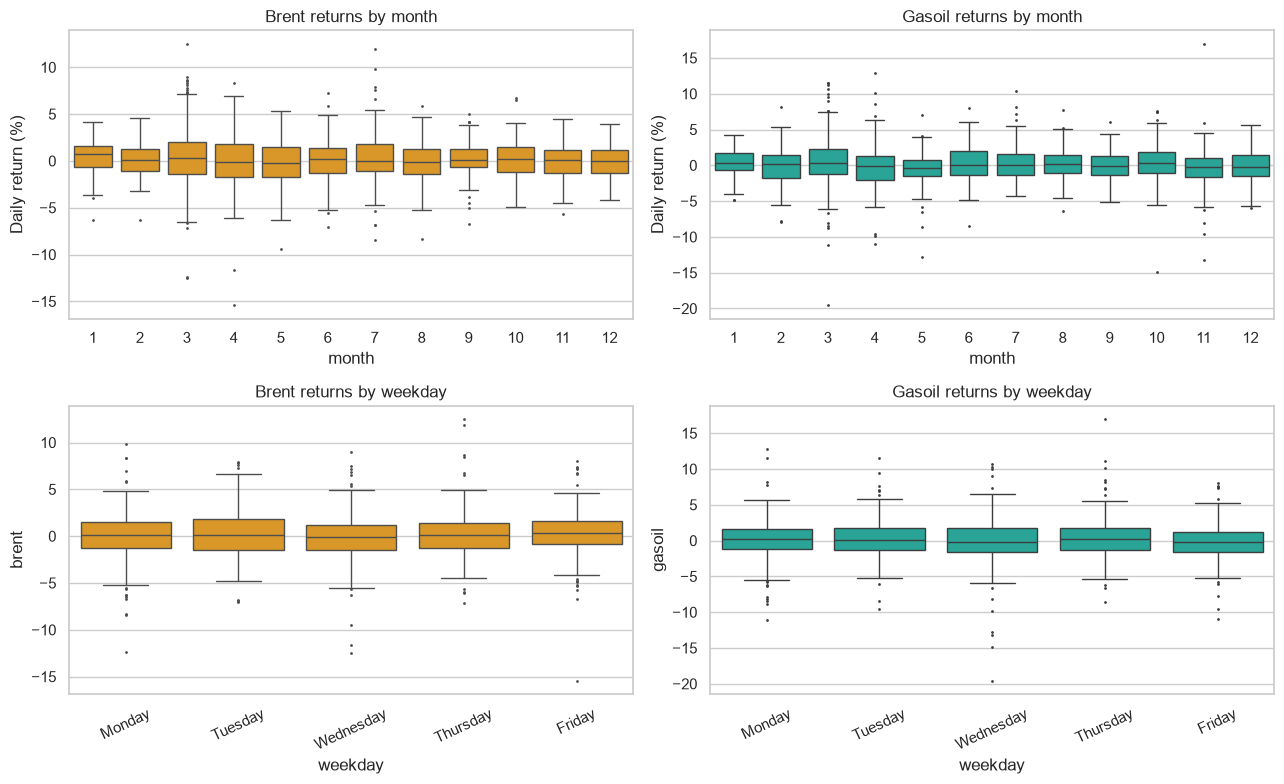

In [6]:
seasonal = returns.assign(
    month=returns.index.month,
    weekday=returns.index.day_name(),
).dropna(subset=['brent', 'gasoil'])
month_order = list(range(1, 13))
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.boxplot(data=seasonal, x='month', y='brent', order=month_order, color='#f59e0b', ax=axes[0, 0], fliersize=1)
axes[0, 0].set_title('Brent returns by month')
axes[0, 0].set_ylabel('Daily return (%)')
sns.boxplot(data=seasonal, x='month', y='gasoil', order=month_order, color='#14b8a6', ax=axes[0, 1], fliersize=1)
axes[0, 1].set_title('Gasoil returns by month')
axes[0, 1].set_ylabel('Daily return (%)')
sns.boxplot(data=seasonal, x='weekday', y='brent', order=weekday_order, color='#f59e0b', ax=axes[1, 0], fliersize=1)
axes[1, 0].set_title('Brent returns by weekday')
axes[1, 0].tick_params(axis='x', rotation=25)
sns.boxplot(data=seasonal, x='weekday', y='gasoil', order=weekday_order, color='#14b8a6', ax=axes[1, 1], fliersize=1)
axes[1, 1].set_title('Gasoil returns by weekday')
axes[1, 1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


## 6. Outliers and market shocks

A robust z-score is used on daily returns. The 3.5 threshold is a screening rule, not a claim that every flagged observation is erroneous; genuine market shocks should remain in the data.

,outlier_count,share_of_observations_pct
brent,27,2.10
gasoil,34,2.64


,date,asset,return_pct
257,2022-03-09,gasoil,-19.571397
597,2022-11-03,gasoil,17.005777
2368,2026-04-17,brent,-15.433422
575,2022-10-19,gasoil,-14.934516
615,2022-11-16,gasoil,-13.182309
293,2022-04-04,gasoil,12.852113
355,2022-05-18,gasoil,-12.757937
2318,2026-03-12,brent,12.530226
256,2022-03-09,brent,-12.464334
2332,2026-03-23,brent,-12.354332


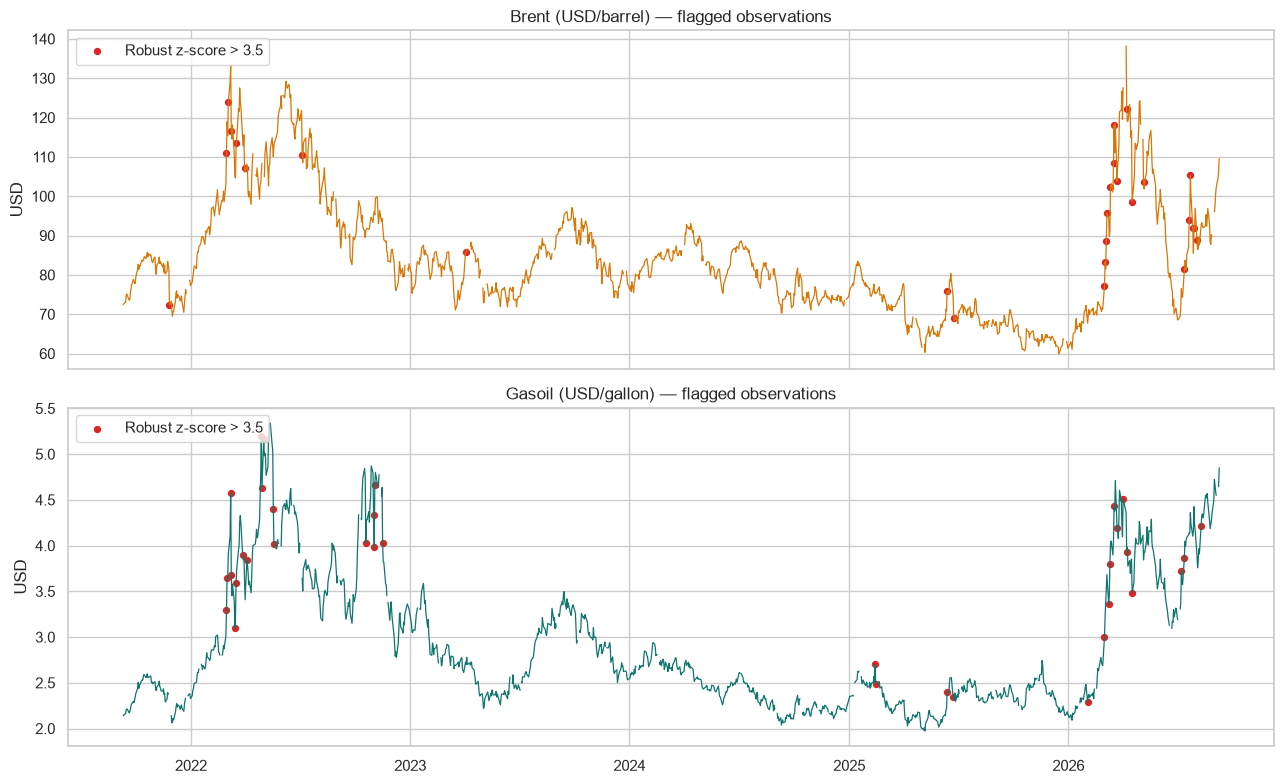

In [7]:
def robust_z_score(series):
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0 or pd.isna(mad):
        return pd.Series(0.0, index=series.index)
    return 0.6745 * (series - median) / mad

robust_z = returns[['brent', 'gasoil']].apply(robust_z_score)
outlier_flags = robust_z.abs() > 3.5
outlier_summary = outlier_flags.sum().rename('outlier_count').to_frame()
outlier_summary['share_of_observations_pct'] = (outlier_summary['outlier_count'] / len(returns) * 100).round(2)
display(outlier_summary)

top_outliers = (
    returns[['brent', 'gasoil']].where(outlier_flags)
    .stack()
    .rename('return_pct')
    .reset_index()
    .rename(columns={'level_1': 'asset'})
)
top_outliers['absolute_return_pct'] = top_outliers['return_pct'].abs()
display(top_outliers.sort_values('absolute_return_pct', ascending=False).head(10).drop(columns='absolute_return_pct'))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, column in zip(axes, ['brent', 'gasoil']):
    ax.plot(df.index, df[column], color=colors[column], linewidth=0.9)
    mask = outlier_flags[column].fillna(False)
    ax.scatter(df.index[mask], df.loc[mask, column], color='#dc2626', s=18, label='Robust z-score > 3.5')
    ax.set_title(f'{labels[column]} — flagged observations')
    ax.set_ylabel('USD')
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 7. Naive baseline forecast

The baseline predicts that the next observation will equal the last observed price. We evaluate it on the final 60 observations of each series, then show a 14-weekday forward baseline (holiday dates are not modeled). Each test prediction uses the immediately preceding actual observation; later test observations are only used after they become available. Any future forecasting model should beat this benchmark before it is considered useful.

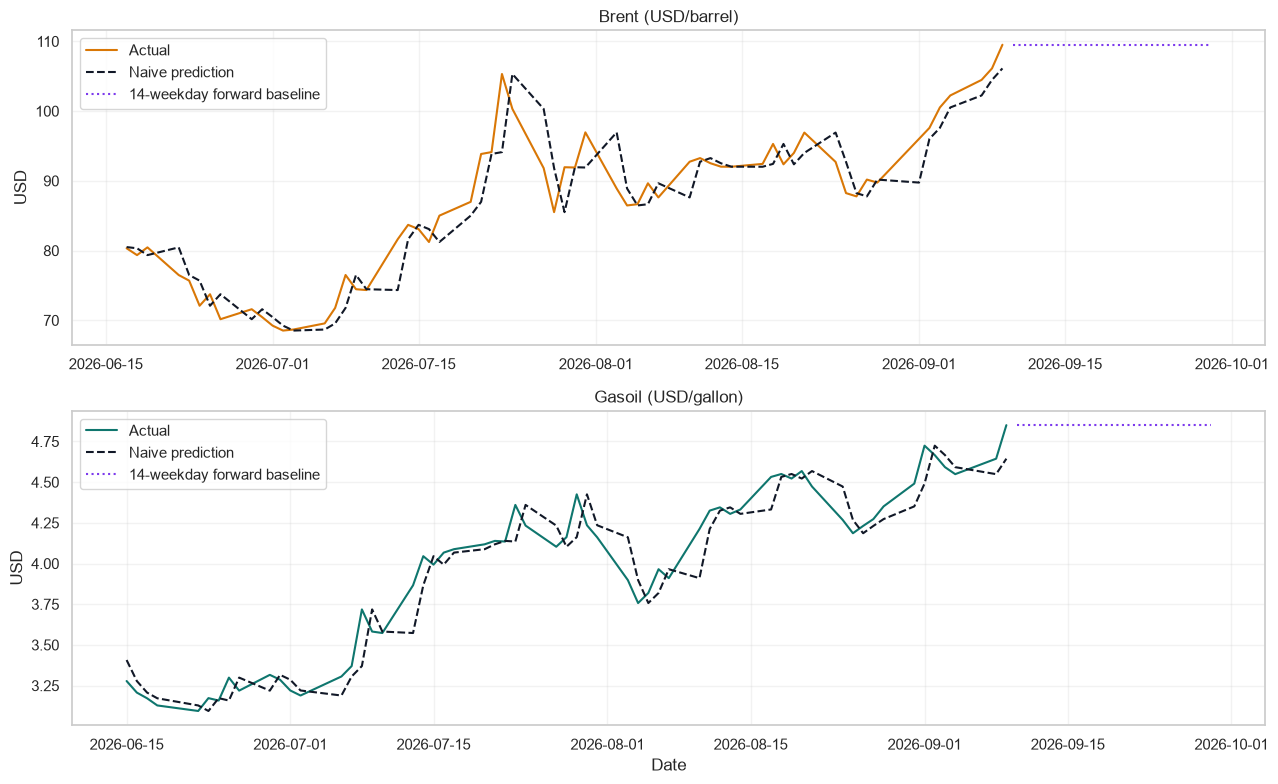

,MAE,RMSE,MAPE (%),holdout observations
brent,2.7128,3.6423,3.0667,60.0
gasoil,0.1021,0.1309,2.5571,60.0


In [8]:
def naive_backtest(series, holdout=60):
    clean = series.dropna()
    train = clean.iloc[:-holdout]
    test = clean.iloc[-holdout:]
    prediction = clean.shift(1).reindex(test.index)
    error = test - prediction
    metrics = {
        'MAE': error.abs().mean(),
        'RMSE': np.sqrt((error ** 2).mean()),
        'MAPE (%)': (error.abs() / test.abs()).mean() * 100,
        'holdout observations': len(test),
    }
    future_index = pd.bdate_range(clean.index[-1] + pd.Timedelta(days=1), periods=14)
    future = pd.Series(clean.iloc[-1], index=future_index)
    return metrics, test, prediction, future

baseline_results = {}
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, column in zip(axes, ['brent', 'gasoil']):
    metrics, test, prediction, future = naive_backtest(df[column])
    baseline_results[column] = metrics
    ax.plot(test.index, test, color=colors[column], label='Actual')
    ax.plot(prediction.index, prediction, color='#111827', linestyle='--', label='Naive prediction')
    ax.plot(future.index, future, color='#7c3aed', linestyle=':', label='14-weekday forward baseline')
    ax.set_title(labels[column])
    ax.set_ylabel('USD')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.25)
plt.xlabel('Date')
plt.tight_layout()
plt.show()

baseline_metrics = pd.DataFrame(baseline_results).T.round(4)
baseline_metrics

## Takeaways

- Use the level charts for business context, but use percentage changes for comparing volatility and co-movement.
- Keep missing market days as missing; do not forward-fill before calculating returns.
- Treat robust outliers as review flags: energy markets can produce genuine shocks.
- The naive forecast is the minimum benchmark for a future ARIMA, exponential-smoothing, or machine-learning model.

The complete feature-engineering and ML experiment is in `data_science_workflow.ipynb`; run `python scripts/run_data_science.py --save-models` from the project root to rebuild its reports. This original notebook is descriptive and must not be used to tune models against the final holdout.
